### **Обработаем категориальные признаки.**

_Считаем данные._

In [27]:
import pandas as pd

df = pd.read_csv('df_after_lesson1.csv')
df

,timestamp,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,...,sport_count_3000,market_count_3000,green_part_5000,prom_part_5000,office_count_5000,trc_sqm_5000,cafe_sum_5000_min_price_avg,mosque_count_5000,market_count_5000,log_price_doc
0,2011-08-20,Investment,Bibirevo,no,no,no,no,no,no,no,...,21,1,13.09,13.31,29,4036616,708.57,1,4,15.581952
1,2011-08-23,Investment,Nagatinskij Zaton,yes,no,no,no,no,no,no,...,19,1,10.26,27.47,66,2034942,673.81,1,14,15.607270
2,2011-08-27,Investment,Tekstil'shhiki,no,no,no,no,yes,no,no,...,20,6,13.69,21.58,43,1572990,702.68,0,10,15.555977
3,2011-09-01,Investment,Mitino,no,no,no,no,no,no,no,...,18,3,14.18,3.89,8,942180,931.58,0,3,16.388123
4,2011-09-05,Investment,Basmannoe,no,no,no,no,yes,yes,no,...,77,5,8.38,10.92,689,3503058,853.88,2,14,16.608603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30466,2015-06-30,Investment,Otradnoe,no,no,yes,no,yes,no,no,...,29,3,15.52,17.24,44,2548292,689.95,1,6,15.816991
30467,2015-06-30,Investment,Tverskoe,yes,no,no,no,yes,yes,no,...,80,4,8.29,12.85,617,4345915,887.43,1,15,17.034386
30468,2015-06-30,OwnerOccupier,Poselenie Vnukovskoe,no,no,no,no,no,no,no,...,6,0,35.62,6.96,1,201300,747.37,0,1,15.757264
30469,2015-06-30,Investment,Obruchevskoe,no,no,no,no,yes,no,no,...,33,4,30.36,9.33,39,1464521,703.20,1,7,16.418200


In [28]:
df.isna().sum()

timestamp                      0
product_type                   0
sub_area                       0
culture_objects_top_25         0
thermal_power_plant_raion      0
                              ..
trc_sqm_5000                   0
cafe_sum_5000_min_price_avg    0
mosque_count_5000              0
market_count_5000              0
log_price_doc                  0
Length: 158, dtype: int64

In [29]:
df.shape

(30471, 158)

_Отберем только категориальные колонки._

In [30]:
cat_cols = df.loc[:, df.dtypes=='string'].columns
cat_cols

Index(['timestamp', 'product_type', 'sub_area', 'culture_objects_top_25',
       'thermal_power_plant_raion', 'incineration_raion',
       'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion',
       'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion',
       'water_1line', 'big_road1_1line', 'railroad_1line', 'ecology'],
      dtype='str')

_Изучим их._

In [31]:
df.describe(include='string')
#или
df.loc[:, cat_cols].describe()

,timestamp,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
count,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471,30471
unique,1161,2,146,2,2,2,2,2,2,2,2,2,2,2,2,5
top,2014-12-16,Investment,Poselenie Sosenskoe,no,no,no,no,no,no,no,no,no,no,no,no,poor
freq,160,19448,1776,28543,28817,28155,30175,19600,29335,27649,29608,27427,28134,29690,29578,8018


_Для колонок с маленьким количеством значений проведем one-hot-encoding, с большим mean-target-encoding._

In [32]:
for col in cat_cols:
    #время не обрабатываем
    if col != 'timestamp':
        #если их мало
        if df[col].nunique() < 5:
            #prefix=col - Добавь material в начало названий новых столбцов
            one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)
            #прикрепим
            df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)
        #если их много
        else:
            mean_target = df.groupby(col)['log_price_doc'].mean()
            df[col] = df[col].map(mean_target)

_Оценим результат._

In [33]:
df.shape

(30471, 158)

### **Обработаем дату.**

_Сделаем отдельные колонки для месяца и года._

In [34]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['month'] = df.timestamp.dt.month
df['year'] = df.timestamp.dt.year
df = df.copy()

C:\Users\user\AppData\Local\Temp\ipykernel_3376\3955873165.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df.timestamp.dt.month
C:\Users\user\AppData\Local\Temp\ipykernel_3376\3955873165.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year'] = df.timestamp.dt.year


In [35]:
df.shape

(30471, 160)

In [36]:
df.head()

,timestamp,sub_area,ecology,id,full_sq,life_sq,floor,max_floor,material,build_year,...,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes,month,year
0,2011-08-20,15.594247,15.628160,1,43,27.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,8,2011
1,2011-08-23,15.864842,15.719018,2,34,19.0,3.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,8,2011
2,2011-08-27,15.613141,15.674436,3,43,29.0,2.0,12.558974,1.827121,3068.057097,...,True,False,False,False,False,False,False,False,8,2011
3,2011-09-01,15.914449,15.628160,4,89,50.0,9.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,9,2011
4,2011-09-05,16.091227,15.719018,5,77,77.0,4.0,12.558974,1.827121,3068.057097,...,True,True,False,False,False,False,False,True,9,2011


### **Графики.**

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

#для начала отсортируем по дате
df = df.sort_values('timestamp')

df.head()

,timestamp,sub_area,ecology,id,full_sq,life_sq,floor,max_floor,material,build_year,...,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes,month,year
0,2011-08-20,15.594247,15.628160,1,43,27.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,8,2011
1,2011-08-23,15.864842,15.719018,2,34,19.0,3.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,8,2011
2,2011-08-27,15.613141,15.674436,3,43,29.0,2.0,12.558974,1.827121,3068.057097,...,True,False,False,False,False,False,False,False,8,2011
3,2011-09-01,15.914449,15.628160,4,89,50.0,9.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,False,False,9,2011
4,2011-09-05,16.091227,15.719018,5,77,77.0,4.0,12.558974,1.827121,3068.057097,...,True,True,False,False,False,False,False,True,9,2011


In [38]:
import seaborn as sns

import seaborn as sns

#тема
sns.set_palette([
    "#E8A2B8",  # розовый
    "#8FBBD9",  # голубой
    "#9BC5A3",  # зелёный
])

_Посмотрим на таргет в каждом году._

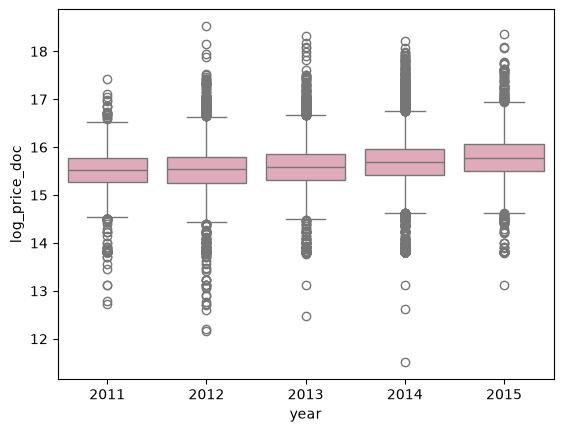

In [39]:
sns.boxplot(y='log_price_doc', x=df['year'].astype('category'), data=df)
plt.show()

_Проведем one-hot-encoding._

In [40]:
one_hot = pd.get_dummies(df['year'], prefix='year', drop_first=True)
df = pd.concat((df.drop('year', axis=1), one_hot), axis=1)

In [41]:
df.head(5)

,timestamp,sub_area,ecology,id,full_sq,life_sq,floor,max_floor,material,build_year,...,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes,month,year_2012,year_2013,year_2014,year_2015
0,2011-08-20,15.594247,15.628160,1,43,27.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,8,False,False,False,False
1,2011-08-23,15.864842,15.719018,2,34,19.0,3.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,8,False,False,False,False
2,2011-08-27,15.613141,15.674436,3,43,29.0,2.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,8,False,False,False,False
3,2011-09-01,15.914449,15.628160,4,89,50.0,9.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,9,False,False,False,False
4,2011-09-05,16.091227,15.719018,5,77,77.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,True,9,False,False,False,False


_Посмотрим на таргет в каждом месяце._

<Axes: xlabel='month', ylabel='log_price_doc'>

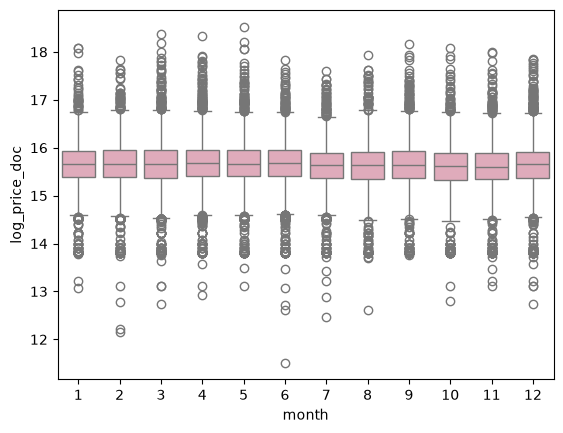

In [42]:
sns.boxplot(y='log_price_doc', x=df['month'].astype('category'), data=df)

_Также проведем one-hot-encoding._

In [43]:
one_hot = pd.get_dummies(df['month'], prefix='month', drop_first=True)
df = pd.concat((df.drop('month', axis=1), one_hot), axis=1)
df.head(5)

,timestamp,sub_area,ecology,id,full_sq,life_sq,floor,max_floor,material,build_year,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2011-08-20,15.594247,15.628160,1,43,27.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,True,False,False,False,False
1,2011-08-23,15.864842,15.719018,2,34,19.0,3.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,True,False,False,False,False
2,2011-08-27,15.613141,15.674436,3,43,29.0,2.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,True,False,False,False,False
3,2011-09-01,15.914449,15.628160,4,89,50.0,9.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,True,False,False,False
4,2011-09-05,16.091227,15.719018,5,77,77.0,4.0,12.558974,1.827121,3068.057097,...,False,False,False,False,False,False,True,False,False,False


_Посмотрим на этаж._

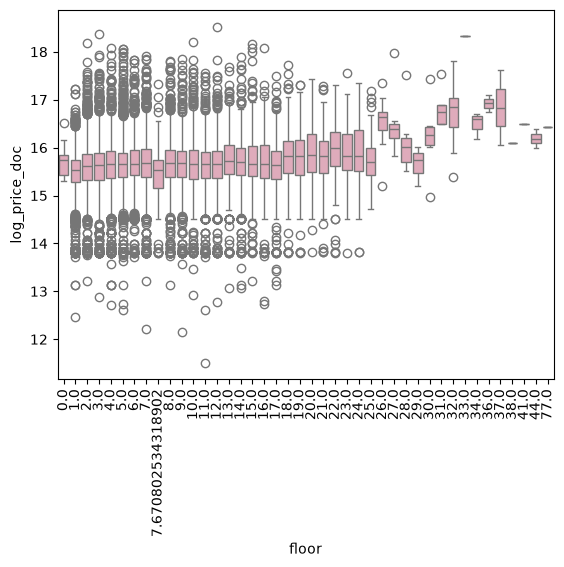

In [44]:
sns.boxplot(y='log_price_doc', x=df['floor'].astype('category'), data=df)
plt.xticks(rotation=90);

_Распределение таргета по типу недвижимости._

<Axes: xlabel='product_type_OwnerOccupier', ylabel='log_price_doc'>

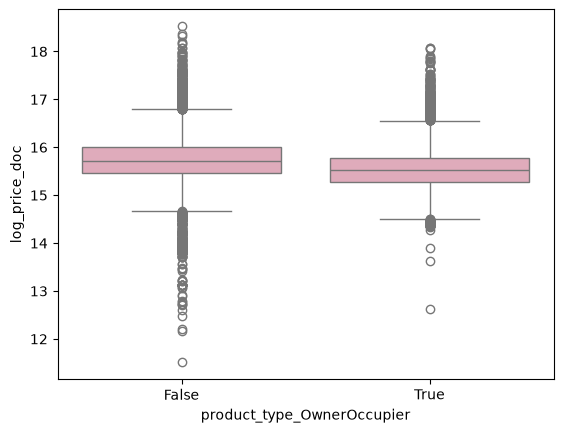

In [45]:
sns.boxplot(y='log_price_doc', x=df['product_type_OwnerOccupier'].astype('category'), data=df)

In [46]:
#уберем колонку со временем
df = df.drop('timestamp', axis=1)

_Определимся с признаками и таргетами._

In [47]:
x = df.drop('log_price_doc', axis=1)
y = df['log_price_doc']

In [48]:
x.isna().sum()

sub_area    0
ecology     0
id          0
full_sq     0
life_sq     0
           ..
month_8     0
month_9     0
month_10    0
month_11    0
month_12    0
Length: 171, dtype: int64

_Сохраним_.

In [49]:
x.to_csv('x_after_lesson_2.csv', index=False)
y.to_csv('y_after_lesson_2.csv', index=False)

In [50]:
df.dtypes

sub_area    float64
ecology     float64
id            int64
full_sq       int64
life_sq     float64
             ...   
month_8        bool
month_9        bool
month_10       bool
month_11       bool
month_12       bool
Length: 172, dtype: object